In [ ]:
!pip install lasio

In [ ]:
import lasio
import pandas as pd

# Read files
las1 = lasio.read("/content/DATA _SET01.txt")
las2 = lasio.read("/content/DATA_SET02.txt")

df1 = las1.df()
df2 = las2.df()

# Merge (outer join → keeps full range 1100–2300)
merged_df = pd.merge(df1, df2, left_index=True, right_index=True, how='outer')

# Sort by depth
merged_df = merged_df.sort_index()

print(merged_df.head())
print(merged_df.tail())

               CDF_x     DT1_x     DT2_x    DT4P_x   DT4S_x  ECGR_x  TENS_x  \
DEPT                                                                          
1168.1460  2089.6290  726.9167  756.8057  377.9358  572.422  6.1651  3309.0   
1168.2984  2035.9484  726.9167  756.8057  377.9358  572.422  5.5387  3296.0   
1168.4508  2065.0994  726.9167  756.8057  377.9358  572.422  6.5011  3312.0   
1168.6032  2050.5239  726.9167  756.8057  377.9358  572.422  7.7109  3302.0   
1168.7556  2055.5009  726.9167  756.8057  377.9358  572.422  8.5180  3325.0   

           VPVS_x  AO10  AO30  ...  HURA  NPHI  PEF8  PEFZ  PR  RHO8  RHOZ  \
DEPT                           ...                                           
1168.1460  1.5146   NaN   NaN  ...   NaN   NaN   NaN   NaN NaN   NaN   NaN   
1168.2984  1.5146   NaN   NaN  ...   NaN   NaN   NaN   NaN NaN   NaN   NaN   
1168.4508  1.5146   NaN   NaN  ...   NaN   NaN   NaN   NaN NaN   NaN   NaN   
1168.6032  1.5146   NaN   NaN  ...   NaN   NaN   NaN   N

In [ ]:
import os
print(os.listdir())

['.config', 'DATA _SET01.txt', 'DATA_SET02.txt', 'sample_data']


In [ ]:
file_path = "DATA_SET02.txt"   # or whatever name appears

In [ ]:
import os
print(os.path.exists(file_path))

True


In [ ]:
import pandas as pd
import numpy as np

file_path = "DATA_SET02.txt"

# Step 1: Read file safely (ignore problematic rows)
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    engine="python",
    header=None,
    on_bad_lines='skip'   # 🔥 key fix
)

print(df.head())
print("Shape:", df.shape)

                                                   0            1
0                                           ~VERSION  INFORMATION
1  #---------------------------------------------...         None
2                                              ~WELL  INFORMATION
3  #---------------------------------------------...         None
4                                         ~PARAMETER  INFORMATION
Shape: (11, 2)


In [ ]:
with open(file_path, 'r') as f:
    for i in range(20):
        print(f.readline())

~VERSION INFORMATION

VERS.           2.0   :CWLS Log ASCII Standard - VERSION 2.0

WRAP.           NO    :One Line per depth step

PROD.  Schlumberger   :LAS Producer

PROG.  DLIS to ASCII 14B0-200                          :LAS Program name and version

CREA.        2010/02/25 15:39                          :LAS Creation date {YYYY/MM/DD hh:mm}

DLIS_CREA.  2010-Feb-25	10:06			       :DLIS Creation date and time {YYYY-MMM-DD hh:mm}

SOURCE.     Chandon_2_WL_S1R1_AIT-PPC-DSI-PEX-HNGS-ECRD_Main_326PUC.DLIS  :DLIS File Name

FILE-ID.     AIT_IS_CAL_DSI_TLD_326PUC                 :File Identification Number

#--------------------------------------------------

~WELL INFORMATION

#MNEM.UNIT      DATA             DESCRIPTION

#---- ------ --------------   -----------------------------

STRT .M      2540.0508       :START DEPTH     

STOP .M      3127.7052       :STOP DEPTH     

STEP .M       0.1524         :STEP     

NULL .          -999.25      :NULL VALUE

COMP .        Chevron Australi

In [ ]:
with open("DATA_SET02.txt", "r") as f:
    for i in range(30):
        print(i, f.readline())

0 ~VERSION INFORMATION

1 VERS.           2.0   :CWLS Log ASCII Standard - VERSION 2.0

2 WRAP.           NO    :One Line per depth step

3 PROD.  Schlumberger   :LAS Producer

4 PROG.  DLIS to ASCII 14B0-200                          :LAS Program name and version

5 CREA.        2010/02/25 15:39                          :LAS Creation date {YYYY/MM/DD hh:mm}

6 DLIS_CREA.  2010-Feb-25	10:06			       :DLIS Creation date and time {YYYY-MMM-DD hh:mm}

7 SOURCE.     Chandon_2_WL_S1R1_AIT-PPC-DSI-PEX-HNGS-ECRD_Main_326PUC.DLIS  :DLIS File Name

8 FILE-ID.     AIT_IS_CAL_DSI_TLD_326PUC                 :File Identification Number

9 #--------------------------------------------------

10 ~WELL INFORMATION

11 #MNEM.UNIT      DATA             DESCRIPTION

12 #---- ------ --------------   -----------------------------

13 STRT .M      2540.0508       :START DEPTH     

14 STOP .M      3127.7052       :STOP DEPTH     

15 STEP .M       0.1524         :STEP     

16 NULL .          -999.25      :N

In [ ]:
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    engine="python",
    header=None,
    skiprows=13,
    on_bad_lines='skip'
)

In [ ]:
# Assign columns
df.columns = [f"col_{i}" for i in range(df.shape[1])]

# 👉 adjust these after seeing df.head()
vp_col = "col_1"
density_col = "col_2"
porosity_col = "col_3"

# Convert to numeric
for col in [vp_col, density_col, porosity_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop NaN
df = df.dropna(subset=[vp_col, density_col, porosity_col])

# Remove invalid values
df = df[
    (df[vp_col] > 0) &
    (df[density_col] > 0) &
    (df[porosity_col] >= 0)
]

# Apply realistic limits
df = df[
    (df[vp_col] < 8000) &
    (df[density_col] < 3.5) &
    (df[porosity_col] < 0.6)
]

clean_df = df[[vp_col, density_col, porosity_col]]

print(clean_df.head())

Empty DataFrame
Columns: [col_1, col_2, col_3]
Index: []


In [ ]:
print(df.head())

Empty DataFrame
Columns: [col_0, col_1, col_2, col_3, col_4]
Index: []


In [ ]:
with open("DATA_SET02.txt", "r") as f:
    content = f.read()

print(content[:500])   # print first 500 characters

~VERSION INFORMATION
VERS.           2.0   :CWLS Log ASCII Standard - VERSION 2.0
WRAP.           NO    :One Line per depth step
PROD.  Schlumberger   :LAS Producer
PROG.  DLIS to ASCII 14B0-200                          :LAS Program name and version
CREA.        2010/02/25 15:39                          :LAS Creation date {YYYY/MM/DD hh:mm}
DLIS_CREA.  2010-Feb-25	10:06			       :DLIS Creation date and time {YYYY-MMM-DD hh:mm}
SOURCE.     Chandon_2_WL_S1R1_AIT-PPC-DSI-PEX-HNGS-ECRD_Main_326PUC.D


In [ ]:
with open("DATA_SET02.txt", "r") as f:
    lines = f.readlines()

print("Total lines:", len(lines))

Total lines: 3947


In [ ]:
for i in range(min(30, len(lines))):
    print(i, repr(lines[i]))

0 '~VERSION INFORMATION\n'
1 'VERS.           2.0   :CWLS Log ASCII Standard - VERSION 2.0\n'
2 'WRAP.           NO    :One Line per depth step\n'
3 'PROD.  Schlumberger   :LAS Producer\n'
4 'PROG.  DLIS to ASCII 14B0-200                          :LAS Program name and version\n'
5 'CREA.        2010/02/25 15:39                          :LAS Creation date {YYYY/MM/DD hh:mm}\n'
6 'DLIS_CREA.  2010-Feb-25\t10:06\t\t\t       :DLIS Creation date and time {YYYY-MMM-DD hh:mm}\n'
7 'SOURCE.     Chandon_2_WL_S1R1_AIT-PPC-DSI-PEX-HNGS-ECRD_Main_326PUC.DLIS  :DLIS File Name\n'
8 'FILE-ID.     AIT_IS_CAL_DSI_TLD_326PUC                 :File Identification Number\n'
9 '#--------------------------------------------------\n'
10 '~WELL INFORMATION\n'
11 '#MNEM.UNIT      DATA             DESCRIPTION\n'
12 '#---- ------ --------------   -----------------------------\n'
13 'STRT .M      2540.0508       :START DEPTH     \n'
14 'STOP .M      3127.7052       :STOP DEPTH     \n'
15 'STEP .M       0.1524     

In [ ]:
import pandas as pd

df = pd.read_csv(
    "DATA_SET02.txt",
    sep=None,              # 🔥 auto-detect delimiter
    engine="python",
    on_bad_lines='skip'
)

print(df.head())
print("Shape:", df.shape)

                                                                                                                                                                                             ~VERSION  \
VERS.      NaN NaN                      NaN NaN NaN                                                NaN      NaN   NaN  NaN   NaN      2.0  NaN NaN  :CWLS        Log    ASCII Standard -      VERSION   
WRAP.      NaN NaN                      NaN NaN NaN                                                NaN      NaN   NaN  NaN   NaN      NO   NaN NaN  NaN          :One   Line  per      depth     step   
PROD.      NaN Schlumberger             NaN NaN :LAS                                               Producer NaN   NaN  NaN   NaN      NaN  NaN NaN  NaN          NaN    NaN   NaN      NaN       None   
DLIS_CREA. NaN 2010-Feb-25\t10:06\t\t\t NaN NaN NaN                                                NaN      NaN   NaN  :DLIS Creation date and time {YYYY-MMM-DD hh:mm} NaN   NaN      NaN       Non

In [ ]:
for i in range(20):
    print(repr(lines[i]))

'~VERSION INFORMATION\n'
'VERS.           2.0   :CWLS Log ASCII Standard - VERSION 2.0\n'
'WRAP.           NO    :One Line per depth step\n'
'PROD.  Schlumberger   :LAS Producer\n'
'PROG.  DLIS to ASCII 14B0-200                          :LAS Program name and version\n'
'CREA.        2010/02/25 15:39                          :LAS Creation date {YYYY/MM/DD hh:mm}\n'
'DLIS_CREA.  2010-Feb-25\t10:06\t\t\t       :DLIS Creation date and time {YYYY-MMM-DD hh:mm}\n'
'SOURCE.     Chandon_2_WL_S1R1_AIT-PPC-DSI-PEX-HNGS-ECRD_Main_326PUC.DLIS  :DLIS File Name\n'
'FILE-ID.     AIT_IS_CAL_DSI_TLD_326PUC                 :File Identification Number\n'
'#--------------------------------------------------\n'
'~WELL INFORMATION\n'
'#MNEM.UNIT      DATA             DESCRIPTION\n'
'#---- ------ --------------   -----------------------------\n'
'STRT .M      2540.0508       :START DEPTH     \n'
'STOP .M      3127.7052       :STOP DEPTH     \n'
'STEP .M       0.1524         :STEP     \n'
'NULL .          -99

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
print(df)

                                                                                                                                                                                                                                                                                          ~VERSION  \
VERS.                                              NaN         NaN                      NaN NaN                  NaN                                                NaN      NaN       NaN  NaN   NaN      2.0                      NaN NaN  :CWLS        Log    ASCII Standard -          VERSION   
WRAP.                                              NaN         NaN                      NaN NaN                  NaN                                                NaN      NaN       NaN  NaN   NaN      NO                       NaN NaN  NaN          :One   Line  per      depth         step   
PROD.                                              NaN         Schlumberger             NaN NaN                  :LAS 

In [ ]:
print(df.columns.tolist())

['~VERSION', 'INFORMATION']


In [ ]:
import lasio

las = lasio.read("DATA_SET02.txt")

df = las.df()

print(df.head())
print(df.columns)

             AO10      AO30    AO90     AORT    AT10     AT30   AT90    ATRT  \
DEPT                                                                           
2540.0508  1950.0  162.0801  1950.0  17.9498  1950.0  34.4663  6.741  2.0329   
2540.2032  1950.0  162.0801  1950.0  17.9498  1950.0  34.4663  6.741  2.0329   
2540.3556  1950.0  162.0801  1950.0  17.9498  1950.0  34.4663  6.741  2.0329   
2540.5080  1950.0  162.0801  1950.0  17.9498  1950.0  34.4663  6.741  2.0329   
2540.6604  1950.0  162.0801  1950.0  17.9498  1950.0  34.4663  6.741  2.0329   

                 CDF    CVEL  ...   HURA    NPHI  PEF8  PEFZ  PR    RHO8  \
DEPT                          ...                                          
2540.0508  2269.1563 -8.0772  ...  0.651  0.5704  10.0  10.0 NaN  4.6281   
2540.2032  2254.5808 -8.0772  ...  0.651  0.5704  10.0  10.0 NaN  4.6281   
2540.3556  2240.0053 -8.0721  ...  0.651  0.5157  10.0  10.0 NaN  4.6281   
2540.5080  2225.4301 -8.0772  ...  0.651  0.5156  10.0  10.

In [ ]:
import numpy as np

# Replace null values
df = df.replace(-999.25, np.nan)

# Correct logs
vp_log = "DT4P"
density_log = "RHOZ"
porosity_log = "NPHI"

# Convert DT → Vp (µs → m/s)
df["Vp"] = 1e6 / df[vp_log]

# Assign directly
df["Density"] = df[density_log]
df["Porosity"] = df[porosity_log]

# Drop missing values
df = df.dropna(subset=["Vp", "Density", "Porosity"])

# Remove unrealistic values
df = df[
    (df["Vp"] > 1000) & (df["Vp"] < 8000) &        # Vp (m/s)
    (df["Density"] > 1.5) & (df["Density"] < 3.5) &  # g/cc
    (df["Porosity"] >= 0) & (df["Porosity"] < 0.6)
]

# Optional: remove outliers (IQR)
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

for col in ["Vp", "Density", "Porosity"]:
    df = remove_outliers(df, col)

# Final clean dataset
clean_df = df[["Vp", "Density", "Porosity"]]

print(clean_df.head())
print(clean_df.describe())

                    Vp  Density  Porosity
DEPT                                     
2544.0132  7564.302242   2.2842    0.4416
2544.1656  7636.117615   2.2691    0.4282
2544.3180  7665.460890   2.2569    0.4402
2544.4704  7665.178855   2.2645    0.4347
2544.6228  7701.691908   2.2858    0.4782
                Vp     Density    Porosity
count   447.000000  447.000000  447.000000
mean   7790.300725    2.270272    0.436548
std     141.891369    0.025950    0.025267
min    7467.094382    2.195200    0.369900
25%    7674.803258    2.255000    0.419400
50%    7814.587960    2.274500    0.436100
75%    7913.693263    2.288150    0.453550
max    7999.712010    2.344300    0.501500


In [ ]:
print(clean_df.isnull().sum())

Vp          0
Density     0
Porosity    0
dtype: int64


In [ ]:
print(clean_df.describe())

                Vp     Density    Porosity
count   447.000000  447.000000  447.000000
mean   7790.300725    2.270272    0.436548
std     141.891369    0.025950    0.025267
min    7467.094382    2.195200    0.369900
25%    7674.803258    2.255000    0.419400
50%    7814.587960    2.274500    0.436100
75%    7913.693263    2.288150    0.453550
max    7999.712010    2.344300    0.501500


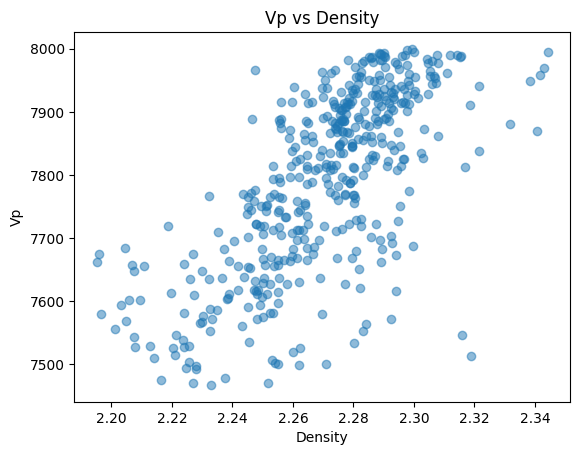

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(clean_df["Density"], clean_df["Vp"], alpha=0.5)
plt.xlabel("Density")
plt.ylabel("Vp")
plt.title("Vp vs Density")
plt.show()

In [ ]:
print(df.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['AO10', 'AO30', 'AO90', 'AORT', 'AT10', 'AT30', 'AT90', 'ATRT', 'CDF',
       'CVEL', 'DT1', 'DT2', 'DT4P', 'DT4S', 'ECGR', 'EHGR', 'GR', 'HCAL',
       'HCGR', 'EHD2_PPC1', 'EHD1_PPC1', 'HDRA', 'HFK', 'HGR', 'HSGR', 'HTHO',
       'HTNP', 'HTPR', 'HTUR', 'HURA', 'NPHI', 'PEF8', 'PEFZ', 'PR', 'RHO8',
       'RHOZ', 'TENS', 'TNPH', 'VPVS', 'Vp', 'Density', 'Porosity'],
      dtype='object')>


In [ ]:
clean_df["Vp"].describe()

,Vp
count,447.000000
mean,7790.300725
std,141.891369
min,7467.094382
25%,7674.803258
50%,7814.587960
75%,7913.693263
max,7999.712010


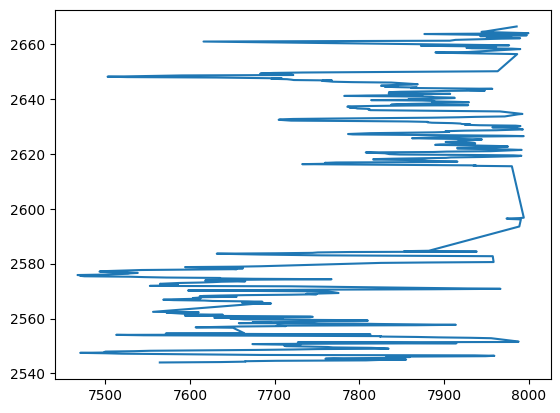

In [ ]:
clean_df = clean_df.reset_index()   # if needed
plt.plot(clean_df["Vp"], clean_df["DEPT"])

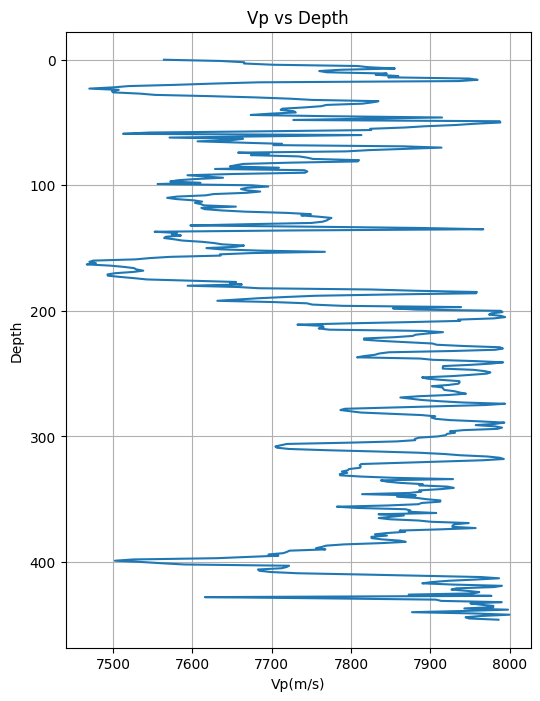

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,8))
plt.plot(clean_df["Vp"], clean_df.index)
plt.xlabel("Vp(m/s)")
plt.ylabel("Depth")
plt.title("Vp vs Depth")
plt.gca().invert_yaxis()   # 🔥 important (depth increases downward)

plt.grid()
plt.show()

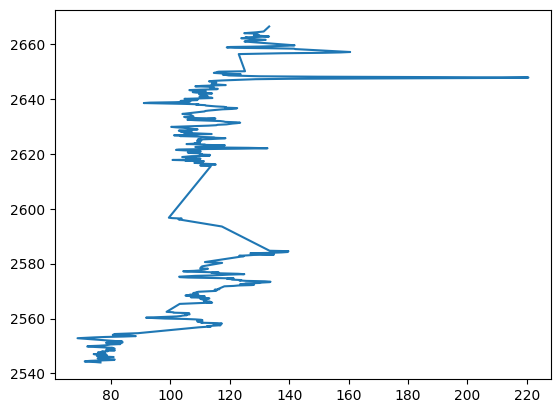

In [ ]:
plt.plot(df["GR"], df.index)

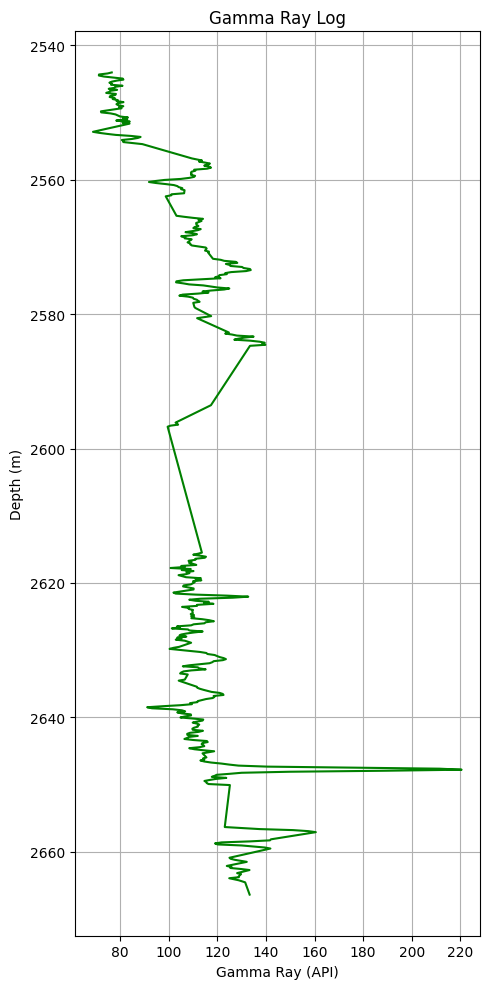

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,10))

plt.plot(df["GR"], df.index, color='green')

plt.xlabel("Gamma Ray (API)")
plt.ylabel("Depth (m)")
plt.title("Gamma Ray Log")

plt.gca().invert_yaxis()   # depth increases downward
plt.grid()

plt.tight_layout()
plt.show()

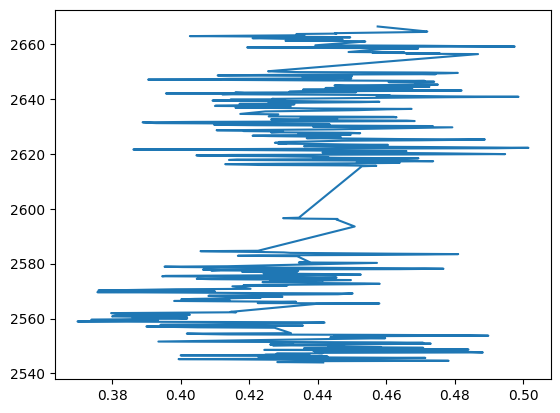

In [ ]:
plt.plot(clean_df["Porosity"], clean_df["DEPT"])

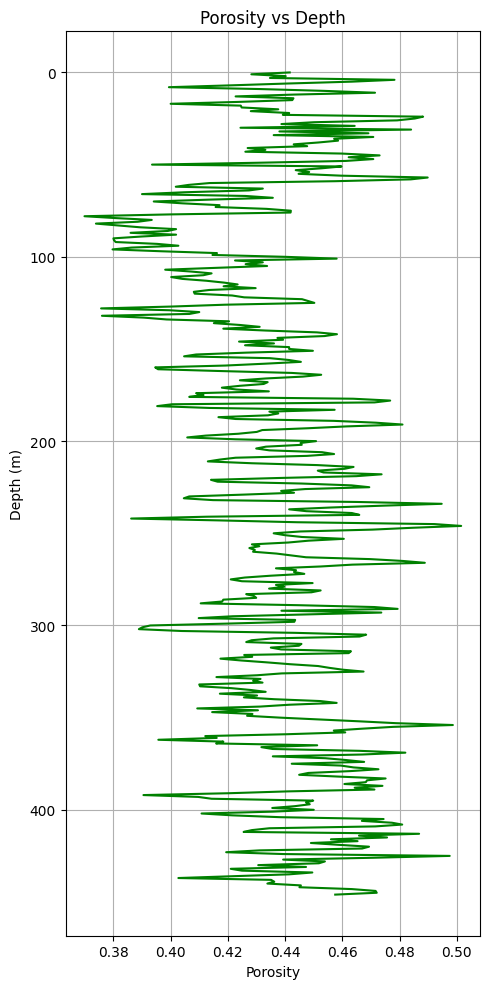

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,10))

plt.plot(clean_df["Porosity"], clean_df.index, color='green')

plt.xlabel("Porosity")
plt.ylabel("Depth (m)")
plt.title("Porosity vs Depth")

plt.gca().invert_yaxis()   # depth increases downward
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("DATASET_N.csv")

# Check first few rows
print(df.head())

# Check columns
print(df.columns)

# Check missing values
print(df.isnull().sum())

        DEPT           Vs  RHO8      GR          Vp  NPHI
0  1168.1460  1347.961047   NaN  6.1651  1470.97666   NaN
1  1168.2984  1347.961047   NaN  5.5387  1470.97666   NaN
2  1168.4508  1347.961047   NaN  6.5011  1470.97666   NaN
3  1168.6032  1347.961047   NaN  7.7109  1470.97666   NaN
4  1168.7556  1347.961047   NaN  8.5180  1470.97666   NaN
Index(['DEPT', 'Vs', 'RHO8', 'GR', 'Vp', 'NPHI'], dtype='object')
DEPT       0
Vs         0
RHO8    9229
GR         0
Vp         4
NPHI    9229
dtype: int64


In [ ]:
df["Vp_ft"]=df["Vp"]*3.281
df["RHOB_est"]=0.23*(df["Vp_ft"]**0.25)
df.drop(columns=["Vp_ft"],inplace=True)
print(df[['Vp', 'RHOB_est']].head())

           Vp  RHOB_est
0  1470.97666  1.917039
1  1470.97666  1.917039
2  1470.97666  1.917039
3  1470.97666  1.917039
4  1470.97666  1.917039


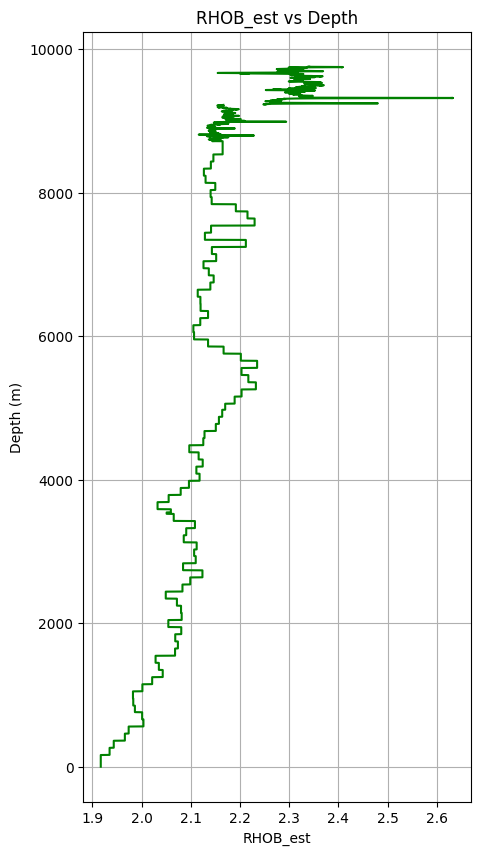

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,10))

plt.plot(df["RHOB_est"], df.index, color='green')
plt.xlabel("RHOB_est")
plt.ylabel("Depth (m)")
plt.title("RHOB_est vs Depth")
plt.grid()
plt.show()

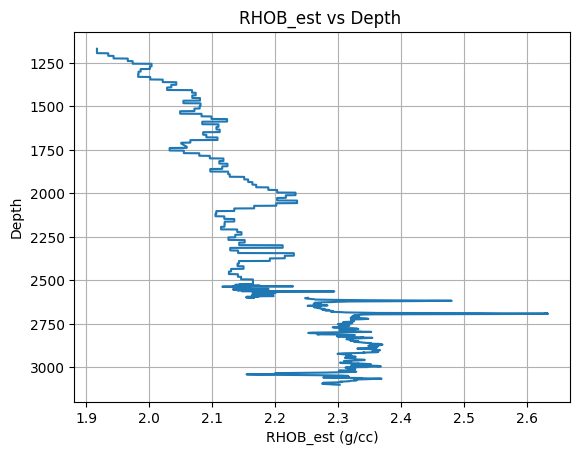

In [ ]:
import matplotlib.pyplot as plt

# Filter depth range
df_filtered = df[(df['DEPT'] >= 1168) & (df['DEPT'] <= 3100)]

# Plot
plt.figure()

plt.plot(df_filtered['RHOB_est'], df_filtered['DEPT'])

# Labels
plt.xlabel('RHOB_est (g/cc)')
plt.ylabel('Depth')

# Invert y-axis (depth increases downward)
plt.gca().invert_yaxis()

# Grid for better readability
plt.grid()

plt.title('RHOB_est vs Depth ')

plt.show()

In [ ]:
# Define constants
rho_matrix = 2.65   # g/cc (sandstone)
rho_fluid = 1.0     # g/cc (water)

# Calculate porosity (NPHI approximation)
df['NPHI_est'] = (rho_matrix - df['RHOB_est']) / (rho_matrix - rho_fluid)

# Optional: limit values between 0 and 1 (physical range)
df['NPHI_est'] = df['NPHI_est'].clip(0, 1)

# View results
print(df[['RHOB_est', 'NPHI_est']].head())

   RHOB_est  NPHI_est
0  1.917039  0.444219
1  1.917039  0.444219
2  1.917039  0.444219
3  1.917039  0.444219
4  1.917039  0.444219


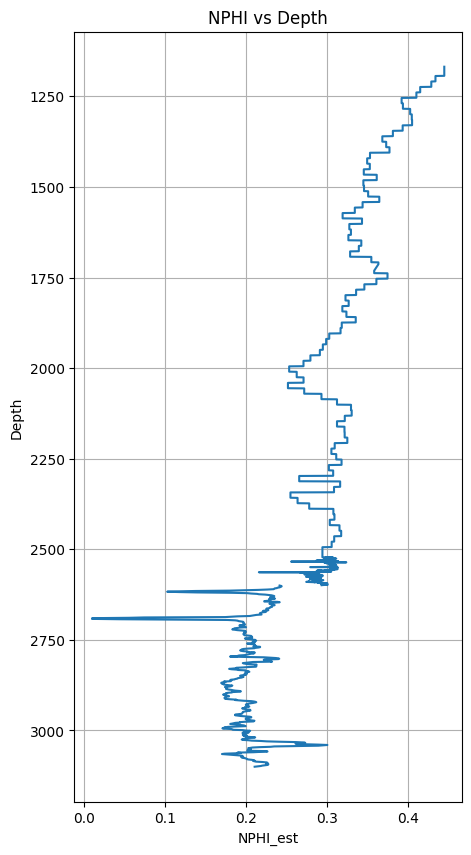

In [ ]:
import matplotlib.pyplot as plt
df_filtered = df[(df['DEPT']>=1168) & (df['DEPT']<=3100)]
plt.figure(figsize=(5,10))
plt.plot(df_filtered['NPHI_est'], df_filtered['DEPT'])
plt.xlabel('NPHI_est')
plt.ylabel('Depth')
plt.gca().invert_yaxis()
plt.grid()
plt.title("NPHI vs Depth")
plt.show()